In [5]:
# ─── Cellule 1 : Imports ───────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Ajouter src au chemin pour importer config.py
sys.path.append(os.path.join(os.getcwd(), "..","src"))
from utils.config import (
    DATA_RAW_2024, DATA_RAW_2025, DATA_RAW_2026,
    DATA_PROCESSED, DATA_INTERIM
)

# Style des graphiques
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("✅ Imports OK")
print(f"   Pandas  : {pd.__version__}")
print(f"   NumPy   : {np.__version__}")

✅ Imports OK
   Pandas  : 3.0.3
   NumPy   : 2.5.0


In [2]:
# ─── Cellule 2 : Chargement des données ───────────────────────────
print("📂 Chargement des données...")

df_2024 = pd.read_csv(DATA_RAW_2024)
df_2025 = pd.read_csv(DATA_RAW_2025)
df_2026 = pd.read_csv(DATA_RAW_2026)

print(f"  2024 : {len(df_2024):>8,} incidents  |  {df_2024.shape[1]} colonnes")
print(f"  2025 : {len(df_2025):>8,} incidents  |  {df_2025.shape[1]} colonnes")
print(f"  2026 : {len(df_2026):>8,} incidents  |  {df_2026.shape[1]} colonnes")
print(f"\n  TOTAL : {len(df_2024)+len(df_2025)+len(df_2026):,} incidents")

📂 Chargement des données...
  2024 :  259,174 incidents  |  22 colonnes
  2025 :  237,461 incidents  |  22 colonnes
  2026 :  103,660 incidents  |  22 colonnes

  TOTAL : 600,295 incidents


In [4]:
# ─── Cellule 3 : Exploration initiale ─────────────────────────────
print("─── Aperçu des données 2024 ───")
display(df_2024.head(3))

print("\n─── Types de colonnes ───")
display(df_2024.dtypes)

print("\n─── Valeurs manquantes (%) ───")
manquants = (df_2024.isnull().sum() / len(df_2024) * 100).round(2)
display(manquants[manquants > 0].sort_values(ascending=False))

─── Aperçu des données 2024 ───


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,...,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,13709672,JJ101940,12/31/2024 11:58:00 PM,014XX E 68TH ST,1310,CRIMINAL DAMAGE,TO PROPERTY,APARTMENT,False,False,...,5,43.0,14,1186817.0,1860189.0,2024,11/02/2025 03:41:09 PM,"41,771470188","-87,59074212",POINT (-87.59074212 41.771470188)
1,13707925,JJ100089,12/31/2024 11:56:00 PM,047XX S DR MARTIN LUTHER KING JR DR,1365,CRIMINAL TRESPASS,TO RESIDENCE,APARTMENT,True,True,...,3,38.0,26,1179661.0,1873623.0,2024,05/17/2025 03:40:52 PM,"41,808500903","-87,616562762",POINT (-87.616562762 41.808500903)
2,13708038,JJ100035,12/31/2024 11:55:00 PM,077XX S CICERO AVE,0498,BATTERY,"AGG. DOMESTIC BATTERY - HANDS, FISTS, FEET, SE...",HOTEL / MOTEL,False,True,...,18,70.0,04B,1145740.0,1853048.0,2024,11/02/2025 03:41:09 PM,"41,752748627","-87,741497836",POINT (-87.741497836 41.752748627)



─── Types de colonnes ───


ID                        int64
Case Number                 str
Date                        str
Block                       str
IUCR                        str
Primary Type                str
Description                 str
Location Description        str
Arrest                     bool
Domestic                   bool
Beat                      int64
District                  int64
Ward                      int64
Community Area          float64
FBI Code                    str
X Coordinate            float64
Y Coordinate            float64
Year                      int64
Updated On                  str
Latitude                    str
Longitude                   str
Location                    str
dtype: object


─── Valeurs manquantes (%) ───


X Coordinate            0.64
Y Coordinate            0.64
Longitude               0.64
Latitude                0.64
Location                0.64
Location Description    0.44
dtype: float64

In [6]:
# ─── Cellule 4 : Fusion ────────────────────────────────────────────
df_2024["annee_source"] = 2024
df_2025["annee_source"] = 2025
df_2026["annee_source"] = 2026

df = pd.concat([df_2024, df_2025, df_2026], ignore_index=True)

print(f"✅ Dataset fusionné : {len(df):,} incidents")
print(f"   Colonnes : {df.shape[1]}")
print(f"   Mémoire  : {df.memory_usage(deep=True).sum() / 1024**2:.1f} Mo")

✅ Dataset fusionné : 600,295 incidents
   Colonnes : 23
   Mémoire  : 197.7 Mo


In [9]:
# ─── Cellule 5 : Nettoyage (corrigé) ─────────────────────────────
print("🧹 Nettoyage en cours...\n")
df_clean = df.copy()
nb_depart = len(df_clean)

# ── 1. Supprimer les doublons ──────────────────────────────────────
doublons = df_clean.duplicated(subset=["ID"]).sum()
df_clean = df_clean.drop_duplicates(subset=["ID"])
print(f"  ✅ Doublons supprimés        : {doublons:,}")

# ── 2. Corriger virgule → point ET convertir en float ─────────────
df_clean["Latitude"]  = df_clean["Latitude"].astype(str).str.replace(",", ".", regex=False)
df_clean["Longitude"] = df_clean["Longitude"].astype(str).str.replace(",", ".", regex=False)
df_clean["Latitude"]  = pd.to_numeric(df_clean["Latitude"],  errors="coerce")
df_clean["Longitude"] = pd.to_numeric(df_clean["Longitude"], errors="coerce")
print(f"  ✅ Virgules → points corrigés")
print(f"     Exemple Latitude  : {df_clean['Latitude'].dropna().iloc[0]}")
print(f"     Exemple Longitude : {df_clean['Longitude'].dropna().iloc[0]}")

# ── 3. Supprimer les lignes sans GPS ──────────────────────────────
sans_gps = df_clean[["Latitude", "Longitude"]].isnull().any(axis=1).sum()
df_clean = df_clean.dropna(subset=["Latitude", "Longitude"])
print(f"  ✅ Lignes sans GPS supprimées : {sans_gps:,}")

# ── 4. Convertir la date en datetime ──────────────────────────────
df_clean["Date"] = pd.to_datetime(df_clean["Date"], format="%m/%d/%Y %I:%M:%S %p", errors="coerce")
dates_invalides = df_clean["Date"].isnull().sum()
df_clean = df_clean.dropna(subset=["Date"])
print(f"  ✅ Dates invalides supprimées : {dates_invalides:,}")

# ── 5. Extraire features temporelles ──────────────────────────────
df_clean["heure"]        = df_clean["Date"].dt.hour
df_clean["jour_semaine"] = df_clean["Date"].dt.dayofweek
df_clean["mois"]         = df_clean["Date"].dt.month
df_clean["trimestre"]    = df_clean["Date"].dt.quarter
df_clean["est_weekend"]  = df_clean["jour_semaine"].isin([5, 6]).astype(int)
df_clean["est_nuit"]     = df_clean["heure"].apply(lambda h: 1 if (h >= 22 or h <= 5) else 0)
print(f"  ✅ Features temporelles créées")

# ── 6. Nettoyer les colonnes texte ────────────────────────────────
df_clean["Primary Type"]         = df_clean["Primary Type"].str.strip().str.upper()
df_clean["Location Description"] = df_clean["Location Description"].str.strip().str.upper()
df_clean["District"]             = pd.to_numeric(df_clean["District"], errors="coerce")
df_clean["Community Area"]       = pd.to_numeric(df_clean["Community Area"], errors="coerce")
print(f"  ✅ Colonnes texte normalisées")

# ── 7. Supprimer les colonnes inutiles ────────────────────────────
colonnes_a_supprimer = ["Case Number", "IUCR", "FBI Code",
                         "X Coordinate", "Y Coordinate",
                         "Updated On", "Location"]
df_clean = df_clean.drop(columns=colonnes_a_supprimer, errors="ignore")
print(f"  ✅ Colonnes inutiles supprimées")

# ── Bilan ──────────────────────────────────────────────────────────
nb_final = len(df_clean)
pct_garde = (nb_final / nb_depart) * 100
print(f"\n  📊 Bilan nettoyage :")
print(f"     Avant  : {nb_depart:>10,} lignes")
print(f"     Après  : {nb_final:>10,} lignes")
print(f"     Gardé  : {pct_garde:.1f}%")
print(f"     Colonnes restantes : {df_clean.shape[1]}")

🧹 Nettoyage en cours...

  ✅ Doublons supprimés        : 0
  ✅ Virgules → points corrigés
     Exemple Latitude  : 41.771470188
     Exemple Longitude : -87.59074212
  ✅ Lignes sans GPS supprimées : 3,240
  ✅ Dates invalides supprimées : 0
  ✅ Features temporelles créées
  ✅ Colonnes texte normalisées
  ✅ Colonnes inutiles supprimées

  📊 Bilan nettoyage :
     Avant  :    600,295 lignes
     Après  :    597,055 lignes
     Gardé  : 99.5%
     Colonnes restantes : 22


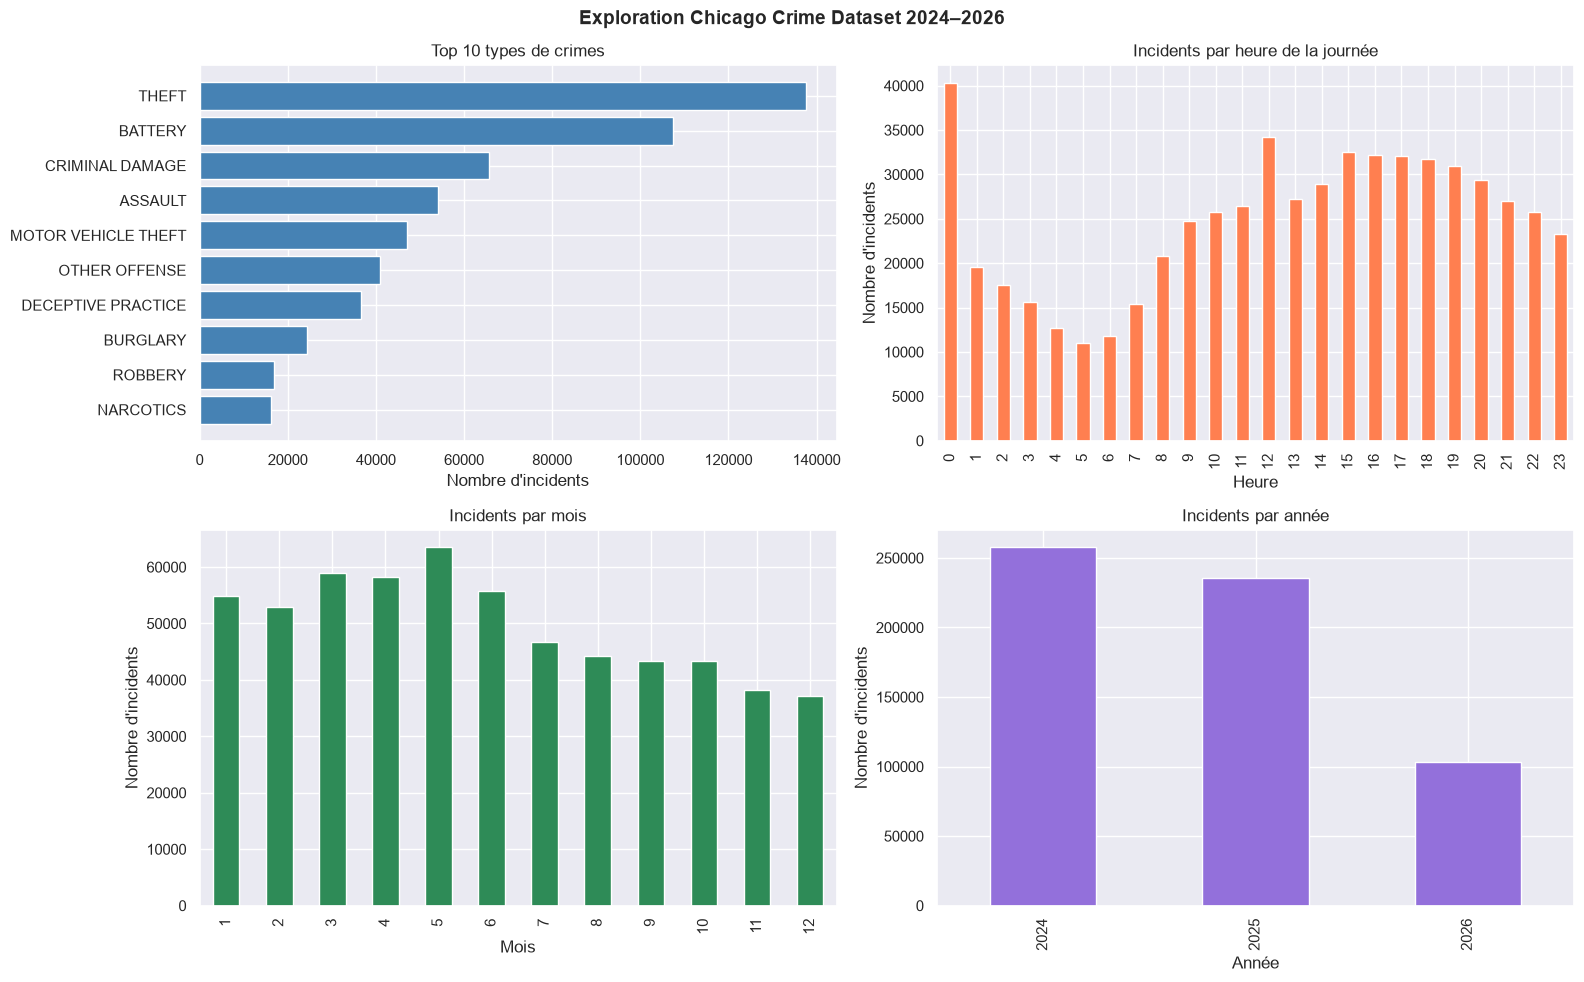

✅ Graphique sauvegardé dans reports/figures/


In [10]:
# ─── Cellule 6 : Visualisations ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Exploration Chicago Crime Dataset 2024–2026", fontsize=14, fontweight="bold")

# ── Graphique 1 : Top 10 types de crimes ──────────────────────────
top_crimes = df_clean["Primary Type"].value_counts().head(10)
axes[0, 0].barh(top_crimes.index[::-1], top_crimes.values[::-1], color="steelblue")
axes[0, 0].set_title("Top 10 types de crimes")
axes[0, 0].set_xlabel("Nombre d'incidents")

# ── Graphique 2 : Distribution par heure ──────────────────────────
df_clean["heure"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0, 1], color="coral"
)
axes[0, 1].set_title("Incidents par heure de la journée")
axes[0, 1].set_xlabel("Heure")
axes[0, 1].set_ylabel("Nombre d'incidents")

# ── Graphique 3 : Distribution par mois ───────────────────────────
df_clean["mois"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1, 0], color="seagreen"
)
axes[1, 0].set_title("Incidents par mois")
axes[1, 0].set_xlabel("Mois")
axes[1, 0].set_ylabel("Nombre d'incidents")

# ── Graphique 4 : Incidents par année ─────────────────────────────
df_clean["annee_source"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1, 1], color="mediumpurple"
)
axes[1, 1].set_title("Incidents par année")
axes[1, 1].set_xlabel("Année")
axes[1, 1].set_ylabel("Nombre d'incidents")

plt.tight_layout()

# Sauvegarder
os.makedirs("../reports/figures", exist_ok=True)
plt.savefig("../reports/figures/exploration_generale.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé dans reports/figures/")

In [11]:
# ─── Cellule 7 : Sauvegarde ───────────────────────────────────────
os.makedirs("../data/processed", exist_ok=True)

chemin_sortie = "../data/processed/crimes_clean.csv"
df_clean.to_csv(chemin_sortie, index=False)

taille_mo = os.path.getsize(chemin_sortie) / (1024 * 1024)
print(f"✅ Données nettoyées sauvegardées !")
print(f"   Fichier  : {chemin_sortie}")
print(f"   Taille   : {taille_mo:.1f} Mo")
print(f"   Lignes   : {len(df_clean):,}")
print(f"   Colonnes : {df_clean.shape[1]}")
print(f"\n   Colonnes disponibles :")
for col in df_clean.columns:
    print(f"     - {col}")

✅ Données nettoyées sauvegardées !
   Fichier  : ../data/processed/crimes_clean.csv
   Taille   : 97.0 Mo
   Lignes   : 597,055
   Colonnes : 22

   Colonnes disponibles :
     - ID
     - Date
     - Block
     - Primary Type
     - Description
     - Location Description
     - Arrest
     - Domestic
     - Beat
     - District
     - Ward
     - Community Area
     - Year
     - Latitude
     - Longitude
     - annee_source
     - heure
     - jour_semaine
     - mois
     - trimestre
     - est_weekend
     - est_nuit
